In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from solidification.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




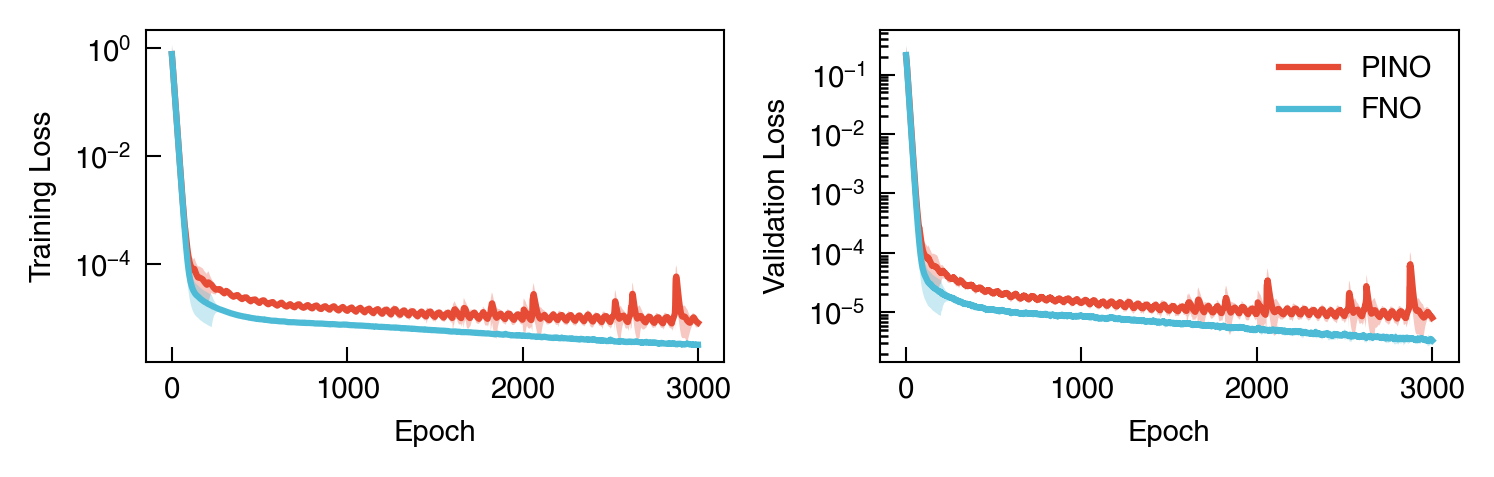

In [3]:
# read csv loss
import pandas as pd
save_dir_pino = "/root/autodl-tmp/runs/solidification/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/solidification/FNO/"
dirs = [
    (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
]
import numpy as np
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.6 * np.abs(ewm_mean))
    
    return ewm_mean, ci


fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    loss_df = loss_df[loss_df["Epoch"] <= 3000]
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["TrainLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["ValidLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()

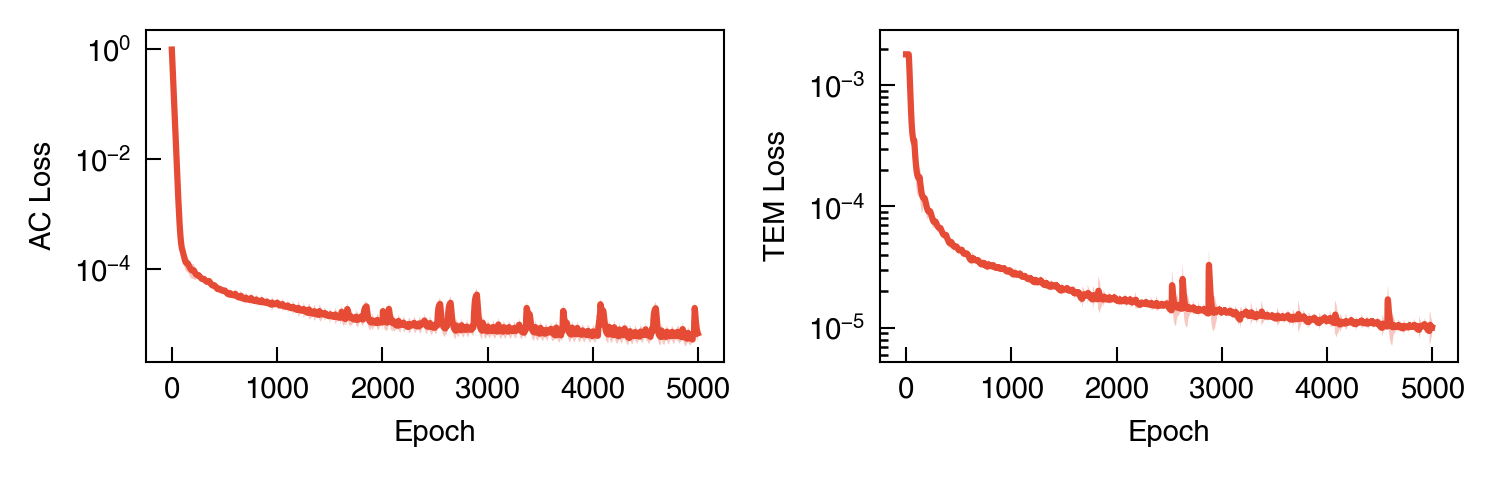

In [4]:
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 1.6))
pino_loss_df = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))

ax = axes[0]
mean, ci = smooth_and_ci_ewma(pino_loss_df["ACLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("AC Loss")

ax = axes[1]
mean, ci = smooth_and_ci_ewma(pino_loss_df["TEMLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("TEM Loss")

fig.tight_layout()

Text(0, 0.5, 'Test MSE Loss (200 steps)')

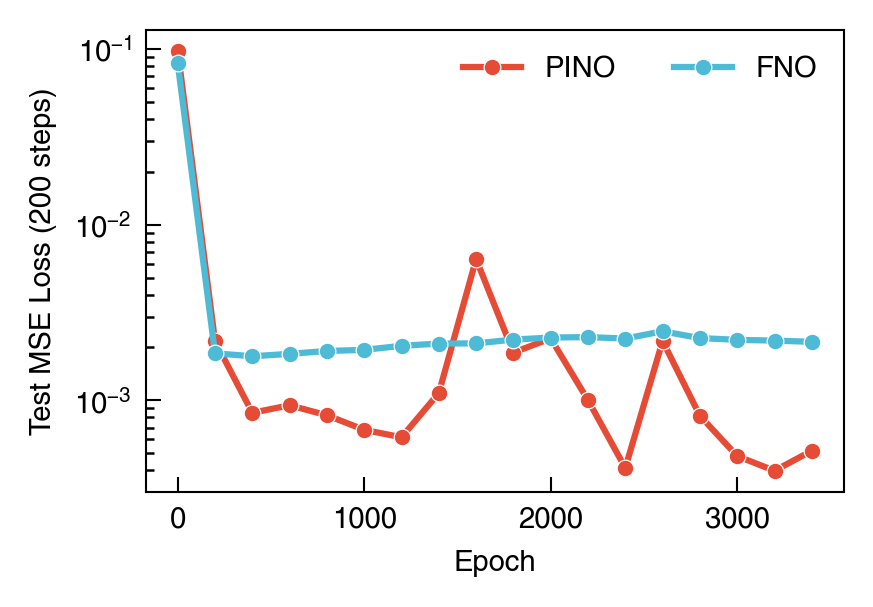

In [5]:

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))
epochs = np.arange(0, 3401, 200)
for dir_path, model_name in dirs:
    # test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
    test_mse = np.load(os.path.join(dir_path, "test_mse.npy"))
    ax.plot(epochs, test_mse, label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
    

ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (200 steps)")